# 🌊 BinWaves Duke (Validation - All Buoys)


> **Inputs:**
> - `Kp_coefficients.nc` file saved in the `outputs/` folder, obtained with the `Propagation Notebook`.
> - OPTIONAL: `buoy_buoy_ID_bulk_parameters.pkl`: wave bulk parameters (Hs, Tp, Dp) stored in the `inputs/buoy_data/` folder.
>
>
> **Outputs:**
> - Plots for each buoy if needed.
> - CSV files with validation data for each buoy saved in `outputs/time_series/` folder.


### BinWaves Validation - All Buoys

This notebook processes **all available buoys** for validation, looping through each one automatically.

**Key Features:**
- Processes all buoys in the `buoys` dictionary
- Handles missing variables gracefully (plots only what's available)
- Saves plots and CSV files for each buoy
- Skips buoys that fail to load (with error messages)


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import os
from pathlib import Path

# Add utils to path
sys.path.append('../utils')
from operations import transform_Offshore_spectrum
from plotting import plot_wave_series
# Note: kp_averaging functions no longer needed - kp_coefficients are pre-aggregated
from bluemath_tk.waves.binwaves import reconstruc_spectra

# Load CAWCR spectrum
cawcr_spectrum = xr.open_dataset(
    "inputs/grid2_superPoint_15D.nc"
)
print("CAWCR spectrum loaded")
cawcr_spectrum


CAWCR spectrum loaded


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 394464, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq       (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    seapoint   int32 4B ...
    station    int64 8B ...
Data variables:
    efth       (time, freq, dir) float64 2GB ...
    latitude   float64 8B ...
    longitude  float64 8B ...

In [2]:
# Define all buoys and their coordinates
buoys = {
     '41109': (-77.300 ,34.484 ),
     '41035': (-77.281 ,34.476),
     '41036': (-76.949 , 34.207),
     '41159': (-76.944, 34.211),
     
     '41108': (-78.016, 33.721), 
     '41110': (-77.715, 34.142),
     
}

print(f"Total buoys to process: {len(buoys)}")
print("Buoy IDs:", list(buoys.keys()))


Total buoys to process: 6
Buoy IDs: ['41109', '41035', '41036', '41159', '41108', '41110']


In [3]:
def find_site_index(kp_coeffs, target_x, target_y, tolerance=1.0):
    """
    Find the site index in kp_coeffs that matches the target coordinates.

    Parameters:
    -----------
    kp_coeffs : xarray.Dataset
        The kp coefficients dataset
    target_x : float
        Target coord_x coordinate
    target_y : float
        Target coord_y coordinate
    tolerance : float
        Tolerance for coordinate matching

    Returns:
    --------
    int
        The site index that matches the coordinates
    """
    # Get all site coordinates
    site_x = kp_coeffs.coord_x.values
    site_y = kp_coeffs.coord_y.values

    # Calculate distances to all sites
    distances = np.sqrt((site_x - target_x) ** 2 + (site_y - target_y) ** 2)

    # Find the site with minimum distance
    site_index = np.argmin(distances)

    # Check if the closest site is within tolerance
    if distances[site_index] > tolerance:
        print(f"Warning: Closest site is {distances[site_index]:.2f} away")

    return site_index


def load_buoy_data(buoy_id, year=None, drop_all_na=False):
    """
    Load buoy data and return both the wave data and location coordinates.
    Modified to handle missing variables gracefully.

    Parameters:
    -----------
    buoy_id : str
        The buoy ID (e.g., '41036')
    year : str, optional
        The year to filter data for (default: None)
    drop_all_na : bool, optional
        If True, drop rows where ALL variables are NaN. If False, only drop rows
        where variables that exist are all NaN (default: False)

    Returns:
    --------
    tuple
        (buoy_waves, buoy_location, kp_coeffs, site_index) or None if loading fails
    """
    try:
        # Load buoy data
        buoy_file = f"../inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl"
        if not os.path.exists(buoy_file):
            print(f"Warning: Buoy file not found: {buoy_file}")
            return None
            
        buoy_waves = pd.read_pickle(buoy_file).sort_index()
      
        # Filter data up to 2023-12-31
        buoy_waves = buoy_waves[buoy_waves.index <= '2023-12-31']
        
        if year:
            buoy_waves = buoy_waves.loc[year]
        
        # Check which columns exist
        available_cols = []
        if "Hs_Buoy" in buoy_waves.columns:
            available_cols.append("Hs_Buoy")
        if "Tp_Buoy" in buoy_waves.columns:
            available_cols.append("Tp_Buoy")
        if "Dir_Buoy" in buoy_waves.columns:
            available_cols.append("Dir_Buoy")
        
        if len(available_cols) == 0:
            print(f"Warning: No valid wave parameters found for buoy {buoy_id}")
            return None
        
        # Only drop rows where ALL available variables are NaN
        # Keep rows that have at least one valid value (even if others are NaN)
        mask = buoy_waves[available_cols].isna().all(axis=1)
        buoy_waves = buoy_waves[~mask]
        
        if len(buoy_waves) == 0:
            print(f"Warning: No valid data after filtering for buoy {buoy_id}")
            return None
        
        # Print info about NaN values for debugging
        nan_counts = {}
        for col in available_cols:
            nan_count = buoy_waves[col].isna().sum()
            nan_counts[col] = nan_count
        if any(nan_counts.values()):
            print(f"NaN counts for buoy {buoy_id}: {nan_counts}")
        
        buoy_location = buoys[buoy_id]

        # Load kp coefficients
        kp_coeffs = xr.open_dataset("outputs/kp_coefficients_averaged.nc")
        site_index = find_site_index(kp_coeffs, buoy_location[0], buoy_location[1])
        kp_coeffs = kp_coeffs.isel(site=[site_index])

        return buoy_waves, buoy_location, kp_coeffs, site_index
    
    except Exception as e:
        print(f"Error loading buoy {buoy_id}: {e}")
        return None


def save_validation_csv_with_interpolation(
    buoy_data: pd.DataFrame,
    binwaves_hs: np.ndarray,
    binwaves_tp: np.ndarray,
    binwaves_dpm: np.ndarray,
    buoy_id: str,
    save_path: str = "outputs",
    filename_prefix: str = "buoy",
    target_resolution: str = "1D",
):
    """
    Save validation data to CSV files, creating hourly data and interpolating to target resolution.
    Modified to handle missing variables.
    
    Parameters:
    -----------
    buoy_data : pd.DataFrame
        Buoy wave data with columns: Hs_Buoy, Tp_Buoy, Dir_Buoy (may be missing)
    binwaves_hs : np.ndarray
        BinWaves significant wave height time series
    binwaves_tp : np.ndarray
        BinWaves peak period time series
    binwaves_dpm : np.ndarray
        BinWaves mean direction time series
    buoy_id : str
        Buoy ID for filename
    save_path : str, optional
        Directory to save the CSV files (default: "outputs")
    filename_prefix : str, optional
        Prefix for the filename (default: "buoy")
    target_resolution : str, optional
        Target resolution for interpolation. Options: "3h", "6h", "1D"/"daily" (default: "1D")
    
    Returns:
    --------
    tuple
        (hourly_filepath, interpolated_filepath) - Paths to both saved CSV files
    """
    print(f"Creating validation data with interpolation to {target_resolution}...")

    # Create directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    # Round the datetime index to the nearest hour to align with the hourly grid
    buoy_data = buoy_data.copy()
    buoy_data.index = pd.to_datetime(buoy_data.index).round('1h')
    # Aggregate duplicate timestamps by taking the mean
    buoy_data = buoy_data.groupby(buoy_data.index).mean()

    # Build DataFrame with available columns
    # Handle NaNs properly - keep them in the data
    data_dict = {'datetime': buoy_data.index}
    
    if 'Hs_Buoy' in buoy_data.columns:
        data_dict['Hs_Buoy'] = buoy_data['Hs_Buoy'].values
        # Ensure binwaves_hs has the same length and handle NaNs
        if len(binwaves_hs) != len(buoy_data):
            print(f"Warning: Length mismatch for Hs - buoy: {len(buoy_data)}, binwaves: {len(binwaves_hs)}")
        data_dict['Hs_BinWaves'] = binwaves_hs[:len(buoy_data)] if len(binwaves_hs) >= len(buoy_data) else np.pad(binwaves_hs, (0, len(buoy_data) - len(binwaves_hs)), constant_values=np.nan)
    
    if 'Tp_Buoy' in buoy_data.columns:
        data_dict['Tp_Buoy'] = buoy_data['Tp_Buoy'].values
        # Ensure binwaves_tp has the same length and handle NaNs
        if len(binwaves_tp) != len(buoy_data):
            print(f"Warning: Length mismatch for Tp - buoy: {len(buoy_data)}, binwaves: {len(binwaves_tp)}")
        data_dict['Tp_BinWaves'] = binwaves_tp[:len(buoy_data)] if len(binwaves_tp) >= len(buoy_data) else np.pad(binwaves_tp, (0, len(buoy_data) - len(binwaves_tp)), constant_values=np.nan)
    
    if 'Dir_Buoy' in buoy_data.columns:
        data_dict['Dir_Buoy'] = buoy_data['Dir_Buoy'].values
        # Ensure binwaves_dpm has the same length and handle NaNs
        if len(binwaves_dpm) != len(buoy_data):
            print(f"Warning: Length mismatch for Dir - buoy: {len(buoy_data)}, binwaves: {len(binwaves_dpm)}")
        data_dict['Dir_BinWaves'] = binwaves_dpm[:len(buoy_data)] if len(binwaves_dpm) >= len(buoy_data) else np.pad(binwaves_dpm, (0, len(buoy_data) - len(binwaves_dpm)), constant_values=np.nan)

    # Create hourly DataFrame
    hourly_df = pd.DataFrame(data_dict)
    hourly_df.set_index('datetime', inplace=True)

    # Create regular hourly time index for interpolation
    start_time = hourly_df.index.min()
    end_time = hourly_df.index.max()

    # Create hourly time index
    hourly_times = pd.date_range(start=start_time, end=end_time, freq='1h')

    # Reindex to hourly and interpolate, but only for small gaps (e.g., up to 3 hours)
    hourly_df_interpolated = hourly_df.reindex(hourly_times).interpolate(
        method='linear', limit=3, limit_direction='both', limit_area='inside'
    )

    # Create target resolution time index
    if target_resolution == "1D" or target_resolution == "daily":
        target_times = pd.date_range(start=start_time, end=end_time, freq='1D')
    elif target_resolution == "6h":
        target_times = pd.date_range(start=start_time, end=end_time, freq='6h')
    else:
        # Default to 1D if not specified
        target_times = pd.date_range(start=start_time, end=end_time, freq='1D')

    # Interpolate to target resolution
    target_df = hourly_df_interpolated.reindex(target_times).interpolate(method='linear')

    # Save hourly data
    hourly_filename = f"{filename_prefix}_{buoy_id}_1h.csv"
    hourly_filepath = os.path.join(save_path, hourly_filename)
    hourly_df_interpolated.to_csv(hourly_filepath)

    # Save target resolution data
    target_filename = f"{filename_prefix}_{buoy_id}_{target_resolution}.csv"
    target_filepath = os.path.join(save_path, target_filename)
    target_df.to_csv(target_filepath)

    print(f"Hourly data saved as: {hourly_filepath}")
    print(f"Hourly data shape: {hourly_df_interpolated.shape}")
    print(f"{target_resolution} data saved as: {target_filepath}")
    print(f"{target_resolution} data shape: {target_df.shape}")

    return hourly_filepath, target_filepath

print("Helper functions defined")


Helper functions defined


In [4]:
# Load model parameters from averaged swan_cases.csv
# The kp_coefficients are already aggregated to 696 cases in the propagation notebook
swan_cases_averaged = pd.read_csv("CASES/swan_cases_averaged.csv")
model_parameters = swan_cases_averaged.to_dict(orient='list')

print(f"Loaded swan_cases_averaged.csv with {len(swan_cases_averaged)} cases")
print(f"  Directions: {len(swan_cases_averaged['dir'].unique())} unique directions")
print(f"  Frequencies: {len(swan_cases_averaged['freq'].unique())} unique frequencies")
print(f"  Total cases: {len(swan_cases_averaged)} (24 dir × 29 freq = 696)")

# Load kp_coefficients (already aggregated to 696 cases)
kp_coeffs_full = xr.open_dataset("outputs/kp_coefficients_averaged.nc")
print(f"\nLoaded kp_coefficients with {len(kp_coeffs_full.site)} sites")
print(f"kp_coefficients structure:")
print(f"  Dimensions: {kp_coeffs_full.kps.dims}")
print(f"  Shape: {kp_coeffs_full.kps.shape}")
print(f"  Directions: {len(kp_coeffs_full.dir)} directions")
print(f"    Values: {kp_coeffs_full.dir.values[:10]}... (first 10)")
print(f"  Case_nums: {len(kp_coeffs_full.case_num)} cases")
print(f"    Range: {kp_coeffs_full.case_num.values.min()} to {kp_coeffs_full.case_num.values.max()}")
print(f"  Frequencies: {len(kp_coeffs_full.freq)} frequencies")
print(f"\n✓ kp_coefficients already aggregated - no need for case aggregation")


Loaded swan_cases_averaged.csv with 696 cases
  Directions: 24 unique directions
  Frequencies: 29 unique frequencies
  Total cases: 696 (24 dir × 29 freq = 696)

Loaded kp_coefficients with 2283 sites
kp_coefficients structure:
  Dimensions: ('case_num', 'dir', 'site', 'freq')
  Shape: (696, 24, 2283, 29)
  Directions: 24 directions
    Values: [  8.  23.  38.  53.  68.  83.  98. 113. 128. 143.]... (first 10)
  Case_nums: 696 cases
    Range: 0 to 695
  Frequencies: 29 frequencies

✓ kp_coefficients already aggregated - no need for case aggregation


Plotting kp_coefficients for each buoy location (individual plots)...
  ✓ Saved plot for buoy 41109 (site index: 64): outputs/Figures/kp_coefficients_buoy_41109.png
  ✓ Saved plot for buoy 41035 (site index: 65): outputs/Figures/kp_coefficients_buoy_41035.png
  ✓ Saved plot for buoy 41036 (site index: 66): outputs/Figures/kp_coefficients_buoy_41036.png
  ✓ Saved plot for buoy 41159 (site index: 67): outputs/Figures/kp_coefficients_buoy_41159.png
  ✓ Saved plot for buoy 41108 (site index: 61): outputs/Figures/kp_coefficients_buoy_41108.png
  ✓ Saved plot for buoy 41110 (site index: 63): outputs/Figures/kp_coefficients_buoy_41110.png

✓ All individual plots saved in: outputs/Figures/


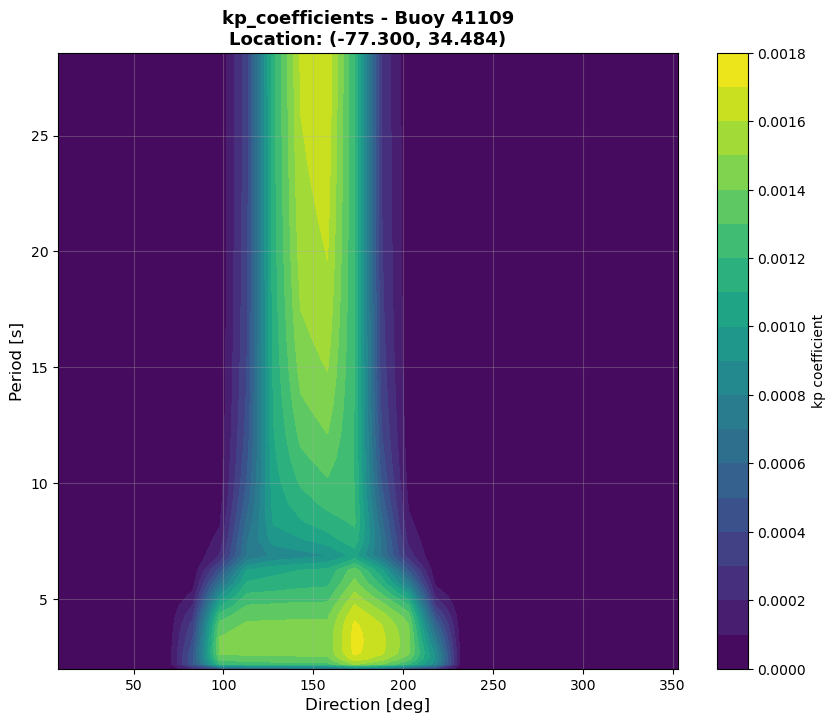

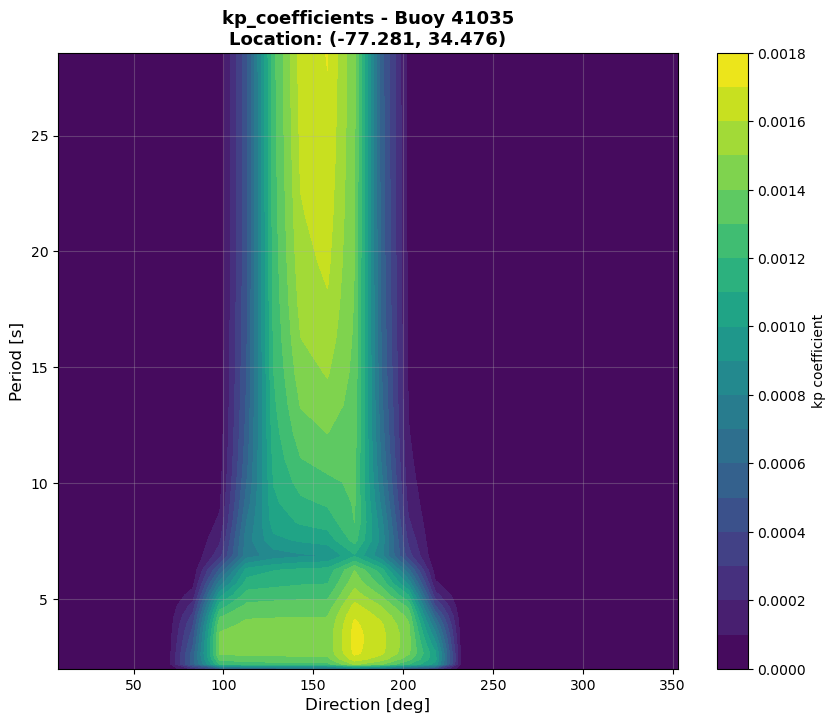

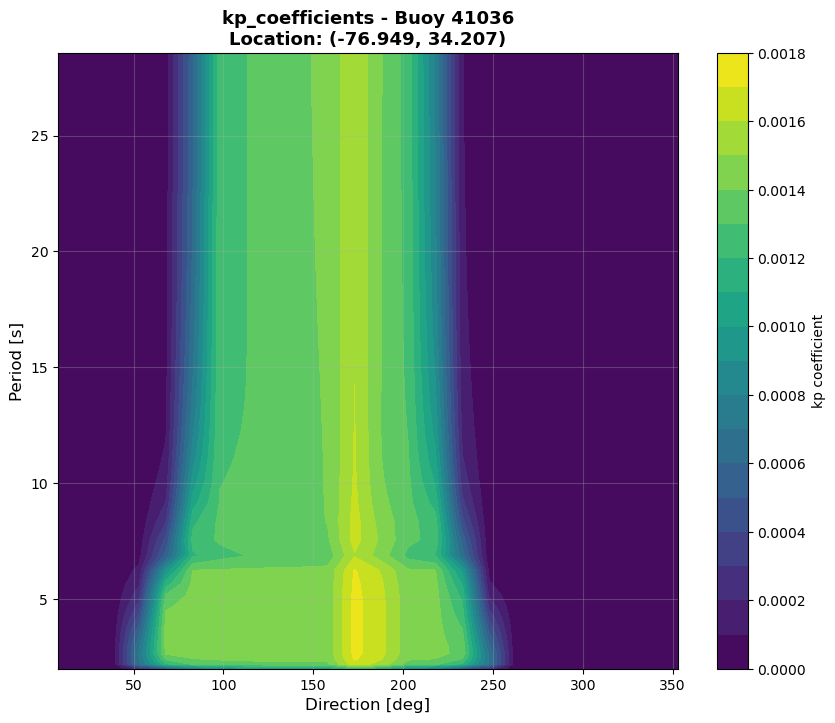

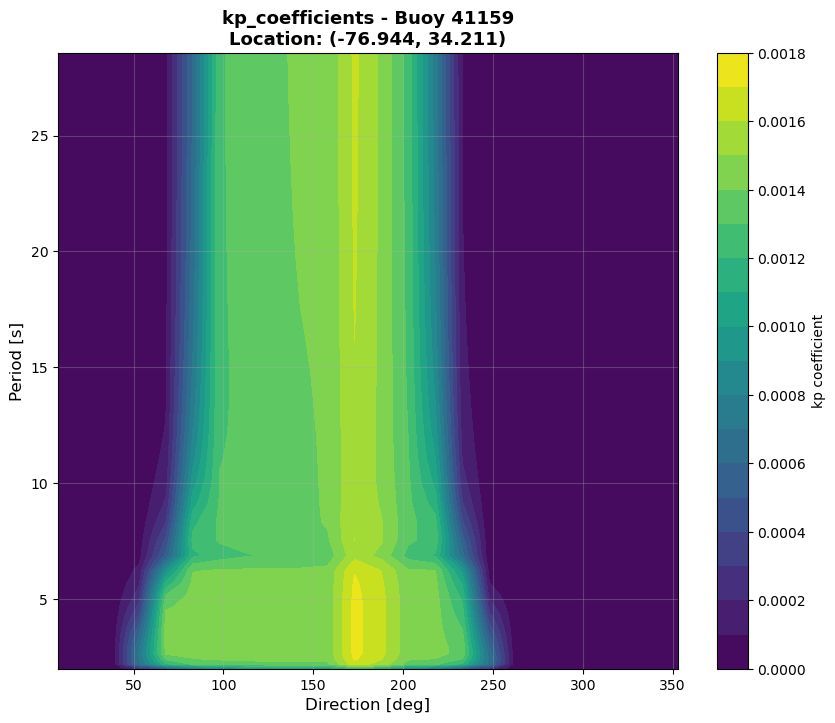

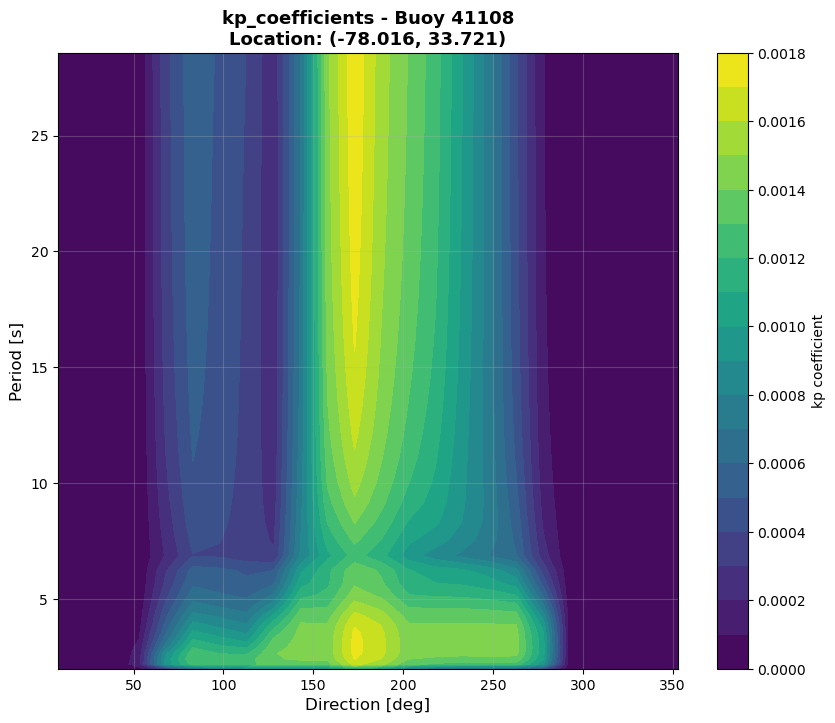

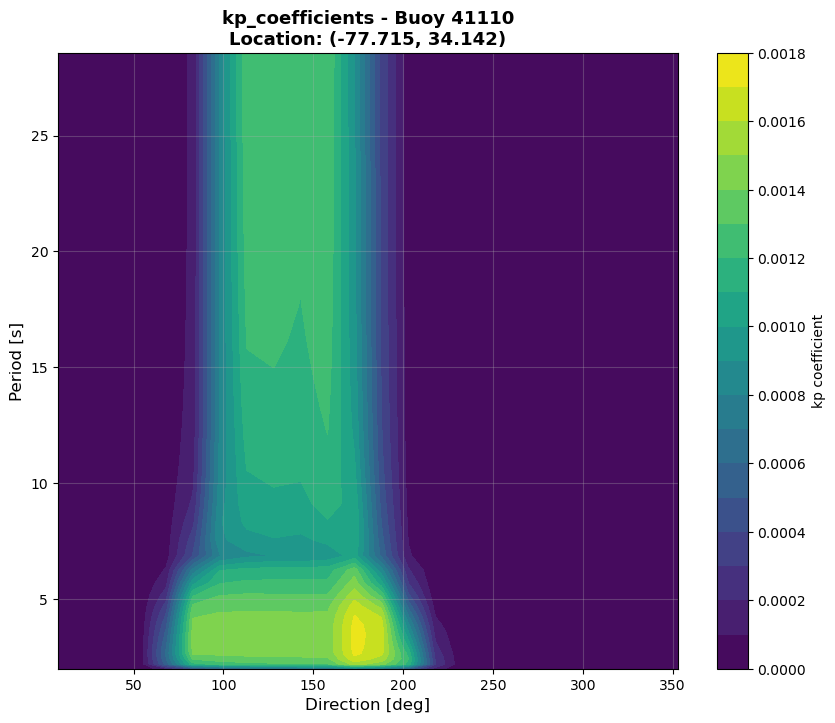

In [5]:
import matplotlib.pyplot as plt

# Plot kp_coefficients for each buoy location - individual plots
print("Plotting kp_coefficients for each buoy location (individual plots)...")

# Create output directory
save_path = "outputs/Figures/"
os.makedirs(save_path, exist_ok=True)

for buoy_id, buoy_location in buoys.items():
    # Create a new figure for each buoy
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Find site index for this buoy
    site_index = find_site_index(kp_coeffs_full, buoy_location[0], buoy_location[1])
    
    # Extract kp_coefficients for this site
    kp_site = kp_coeffs_full.isel(site=[site_index])
    
    # Calculate mean across all cases for visualization using xarray
    # This handles dimensions correctly
    kps_mean = kp_site.kps.mean(dim='case_num').squeeze()
    
    # Get frequency and direction coordinates
    freq = kp_site.freq.values
    dir_deg = kp_site.dir.values
    
    # Convert frequency to period (T = 1/f)
    period = 1.0 / freq
    
    # Convert to numpy array for plotting
    # Ensure dimensions are (freq, dir) = (n_periods, n_directions)
    # Use xarray's transpose to guarantee correct dimension order
    # After averaging: 29 frequencies, 24 directions (72/3 = 24)
    kps_mean_transposed = kps_mean.transpose('freq', 'dir')  # Ensure (freq, dir) order
    kps_mean_values = kps_mean_transposed.values
    
    # Verify dimensions match
    # Should be (29, 24) = (freq, dir) = (n_periods, n_directions)
    assert kps_mean_values.shape[0] == len(freq), f"Frequency dimension mismatch: {kps_mean_values.shape[0]} != {len(freq)} (expected {len(freq)})"
    assert kps_mean_values.shape[1] == len(dir_deg), f"Direction dimension mismatch: {kps_mean_values.shape[1]} != {len(dir_deg)} (expected {len(dir_deg)})"
    
    # Reverse period array and flip data vertically so period is in ascending order
    # (period is in descending order since freq is in ascending order)
    period_sorted = period[::-1]  # Reverse to get ascending order
    kps_mean_values_flipped = np.flipud(kps_mean_values)  # Flip data to match
    
    # Create 2D plot (period vs dir)
    # contourf expects z with shape (n_rows, n_cols) where:
    # n_rows = len(y) = len(period_sorted)
    # n_cols = len(x) = len(dir_deg)
    im = ax.contourf(dir_deg, period_sorted, kps_mean_values_flipped, levels=20, cmap='viridis')
    ax.set_xlabel('Direction [deg]', fontsize=12)
    ax.set_ylabel('Period [s]', fontsize=12)
    ax.set_title(f'kp_coefficients - Buoy {buoy_id}\nLocation: ({buoy_location[0]:.3f}, {buoy_location[1]:.3f})', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(im, ax=ax, label='kp coefficient')
    cbar.ax.tick_params(labelsize=10)
    
    # Save individual figure
    filename = f"kp_coefficients_buoy_{buoy_id}.png"
    filepath = os.path.join(save_path, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved plot for buoy {buoy_id} (site index: {site_index}): {filepath}")
    
    # plt.close(fig)  # Close figure to free memory

print(f"\n✓ All individual plots saved in: {save_path}")


In [6]:
# Configuration for scatter plot style
# Options: "black" (black dots) or "kde" (KDE-colored density)
SCATTER_STYLE = "kde"  # Change to "kde" for density-colored plots
KDE_CMAP = "plasma"     # Colormap for KDE plots (e.g., "viridis", "plasma", "inferno")
KDE_ALPHA = 0.6          # Transparency for scatter points (0.0 to 1.0)

print(f"Scatter plot style: {SCATTER_STYLE}")
if SCATTER_STYLE == "kde":
    print(f"KDE colormap: {KDE_CMAP}")
    print(f"KDE alpha: {KDE_ALPHA}")


Scatter plot style: kde
KDE colormap: plasma
KDE alpha: 0.6


NaN counts for buoy 41109: {'Hs_Buoy': np.int64(0), 'Tp_Buoy': np.int64(13), 'Dir_Buoy': np.int64(26)}
  Buoy 41109: 13324 time steps, 696 cases
NaN counts for buoy 41035: {'Hs_Buoy': np.int64(165), 'Tp_Buoy': np.int64(230), 'Dir_Buoy': np.int64(4291)}
  Buoy 41035: 41923 time steps, 696 cases
NaN counts for buoy 41036: {'Hs_Buoy': np.int64(49), 'Tp_Buoy': np.int64(1466), 'Dir_Buoy': np.int64(1726)}
  Buoy 41036: 63838 time steps, 696 cases
NaN counts for buoy 41159: {'Hs_Buoy': np.int64(0), 'Tp_Buoy': np.int64(0), 'Dir_Buoy': np.int64(59)}
  Buoy 41159: 68741 time steps, 696 cases
NaN counts for buoy 41108: {'Hs_Buoy': np.int64(0), 'Tp_Buoy': np.int64(3), 'Dir_Buoy': np.int64(19)}
  Buoy 41108: 88064 time steps, 696 cases
NaN counts for buoy 41110: {'Hs_Buoy': np.int64(1), 'Tp_Buoy': np.int64(6), 'Dir_Buoy': np.int64(209)}
  Buoy 41110: 127625 time steps, 696 cases

Buoy data time range: 2005-08-01 20:00:00 to 2023-12-31 00:00:00
Total unique case_nums needed: 696
Filtered spectrum fr

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34291 instead
  warnings.warn(
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 70.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Creating plots...


/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


BinWaves Tp: 1671/13324 (12.5%) values < 5s
BinWaves Tp range: [2.42, 16.11]
Buoy Tp: 1989/13311 (14.9%) values < 5s


...

Creating plots...


/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


BinWaves Tp: 14627/127625 (11.5%) values < 5s
BinWaves Tp range: [2.21, 19.68]
Buoy Tp: 16364/127619 (12.8%) values < 5s


/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Tp_Buoy range: [2.04, 22.22]
Tp_BinWaves range: [2.21, 19.68]
Time series plot saved as: outputs/Figures/timeseries_Wave Validation 41110.png
Scatter plot saved as: outputs/Figures/scatter_Wave Validation 41110.png
✓ Plots saved for buoy 41110
Saving CSV files...
Creating validation data with interpolation to 1d...
Hourly data saved as: outputs/time_series/buoy_validation_41110_1h.csv
Hourly data shape: (137165, 6)
1d data saved as: outputs/time_series/buoy_validation_41110_1d.csv
1d data shape: (5716, 6)
✓ CSV files saved for buoy 41110
✓ Successfully processed buoy 41110

Processing complete!
Successfully processed: 6 buoys
Successful buoys: ['41109', '41035', '41036', '41159', '41108', '41110']


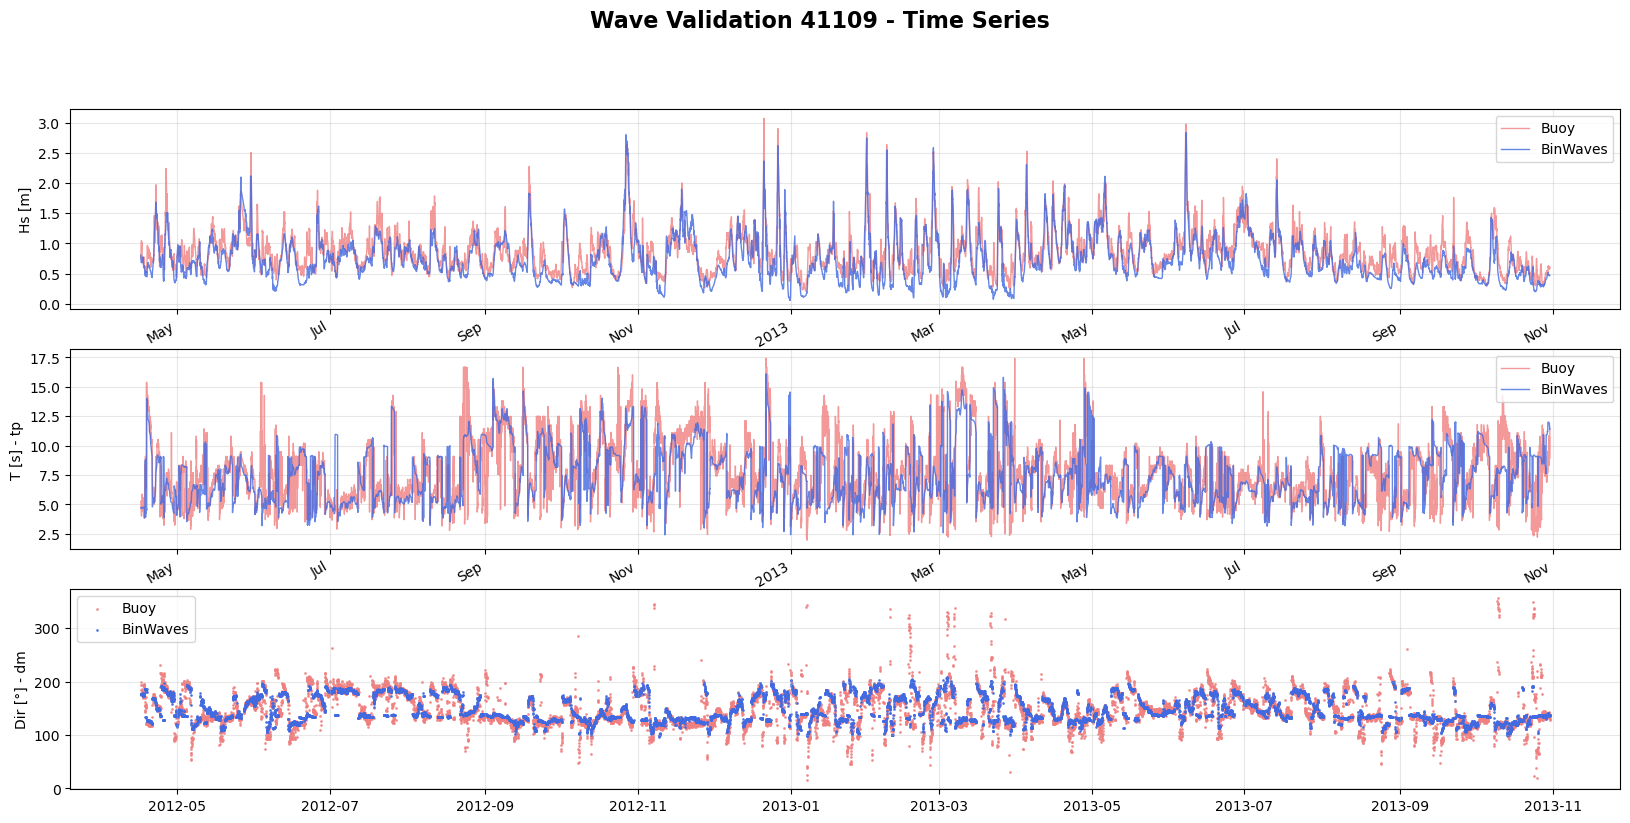

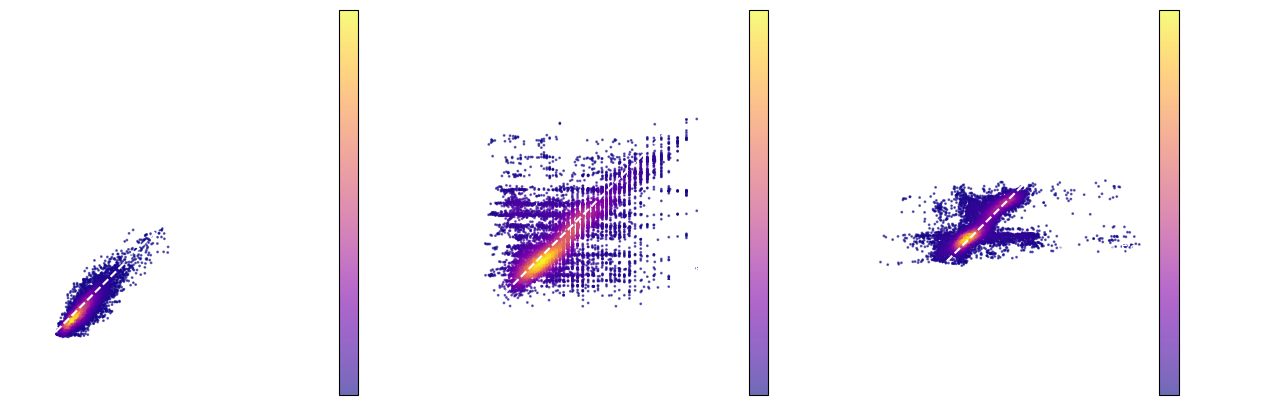

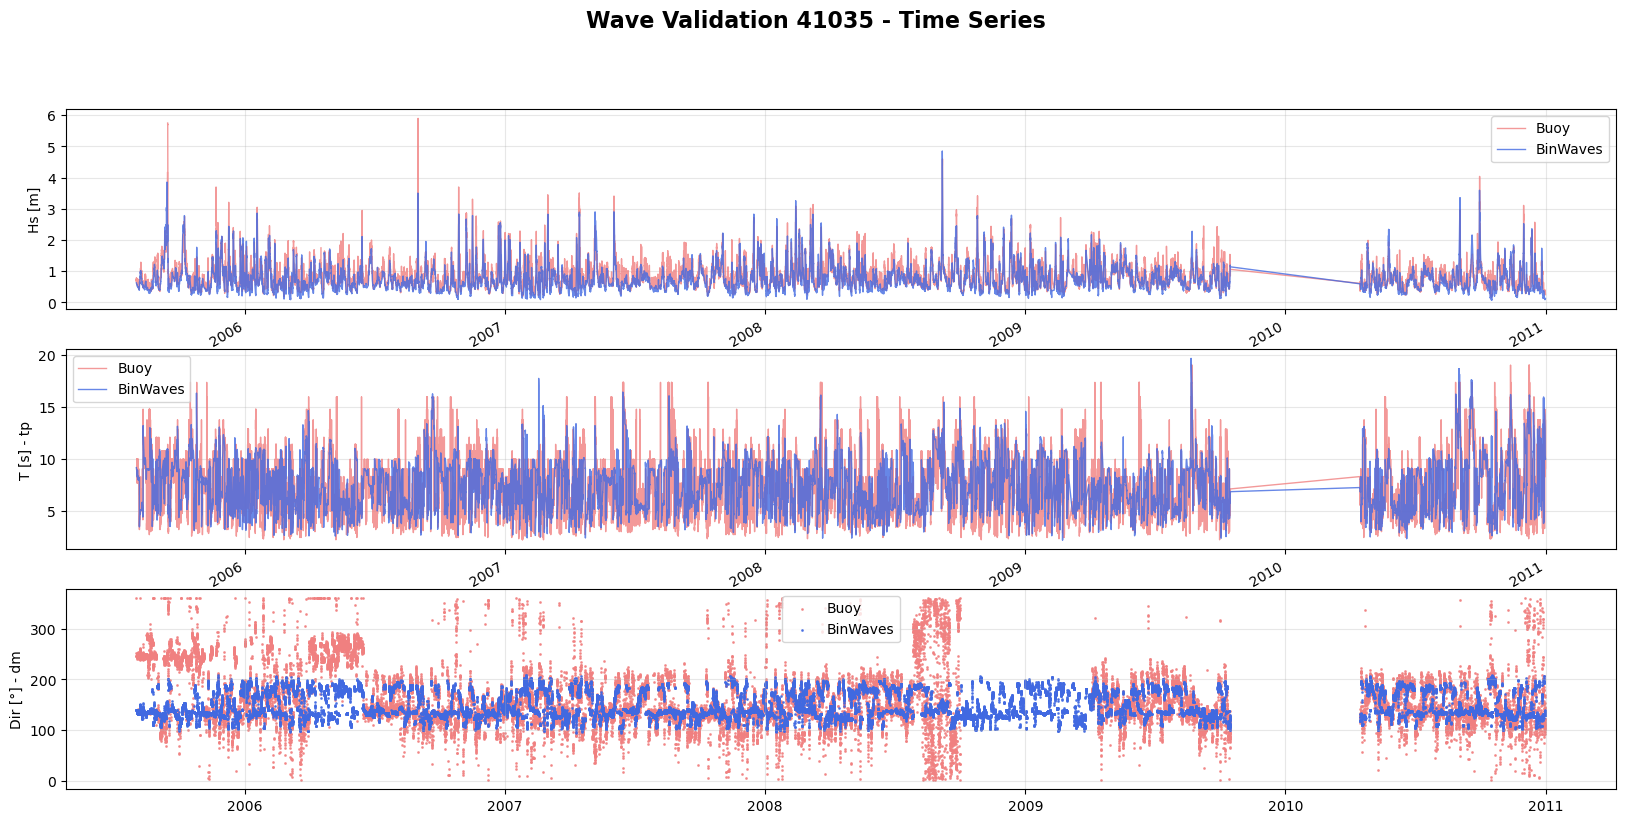

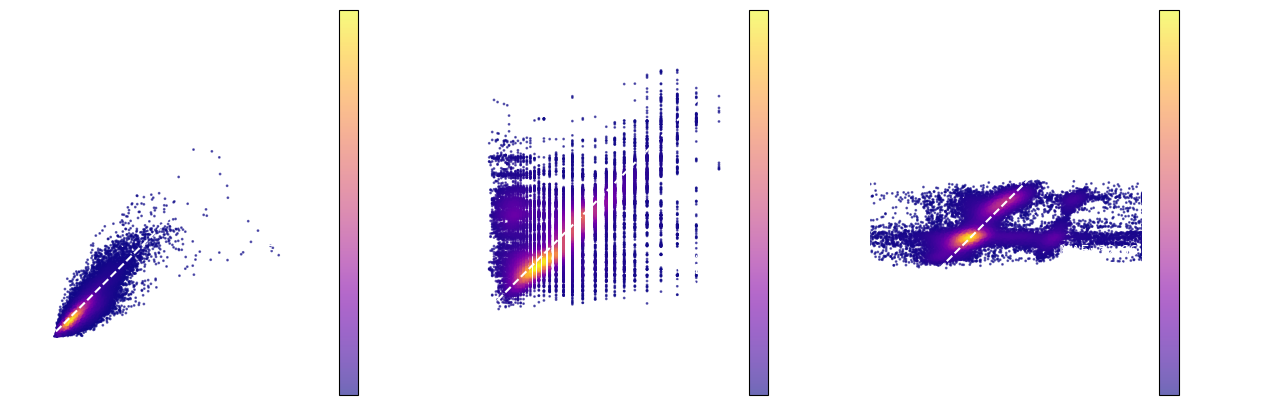

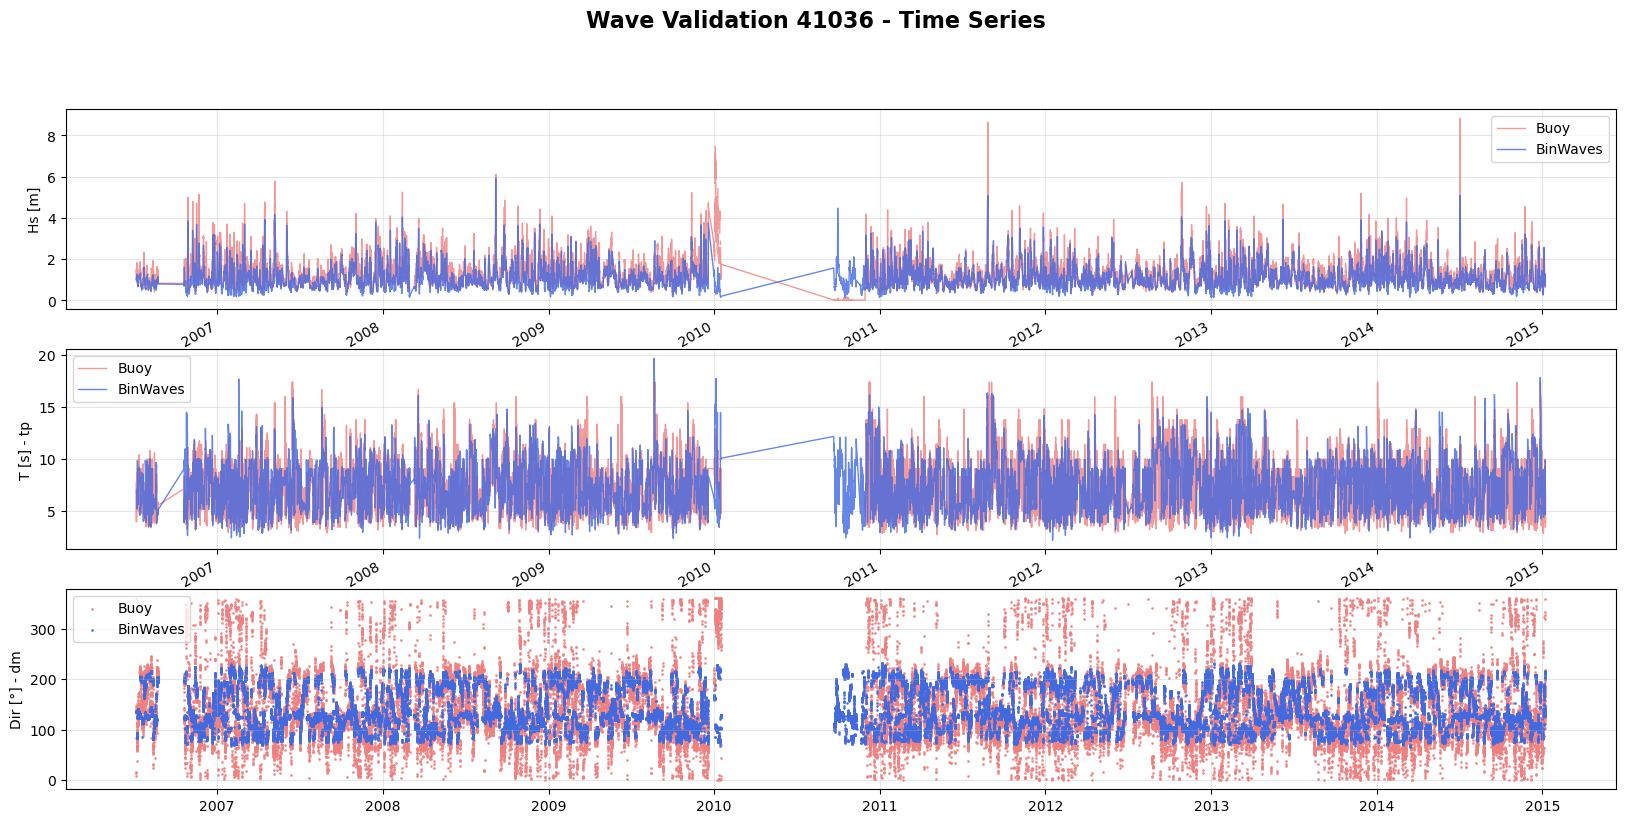

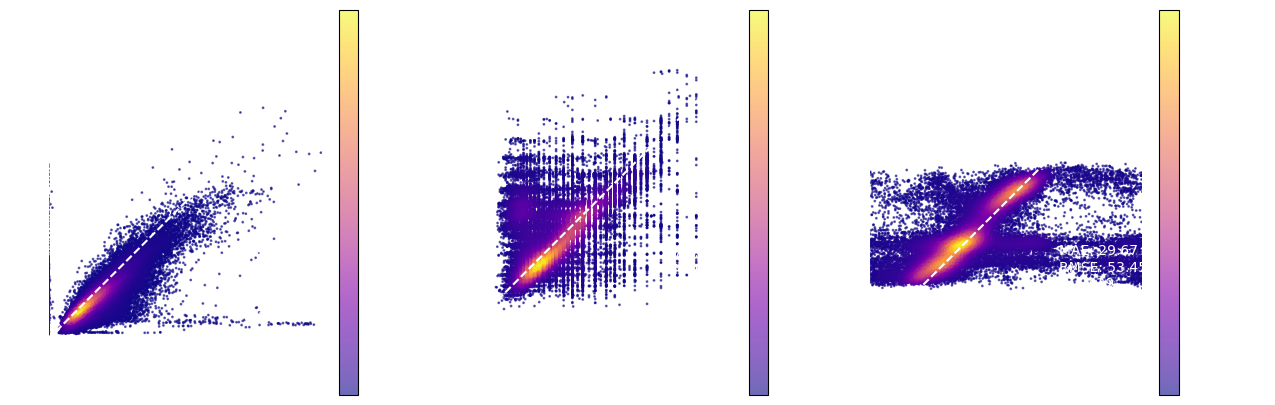

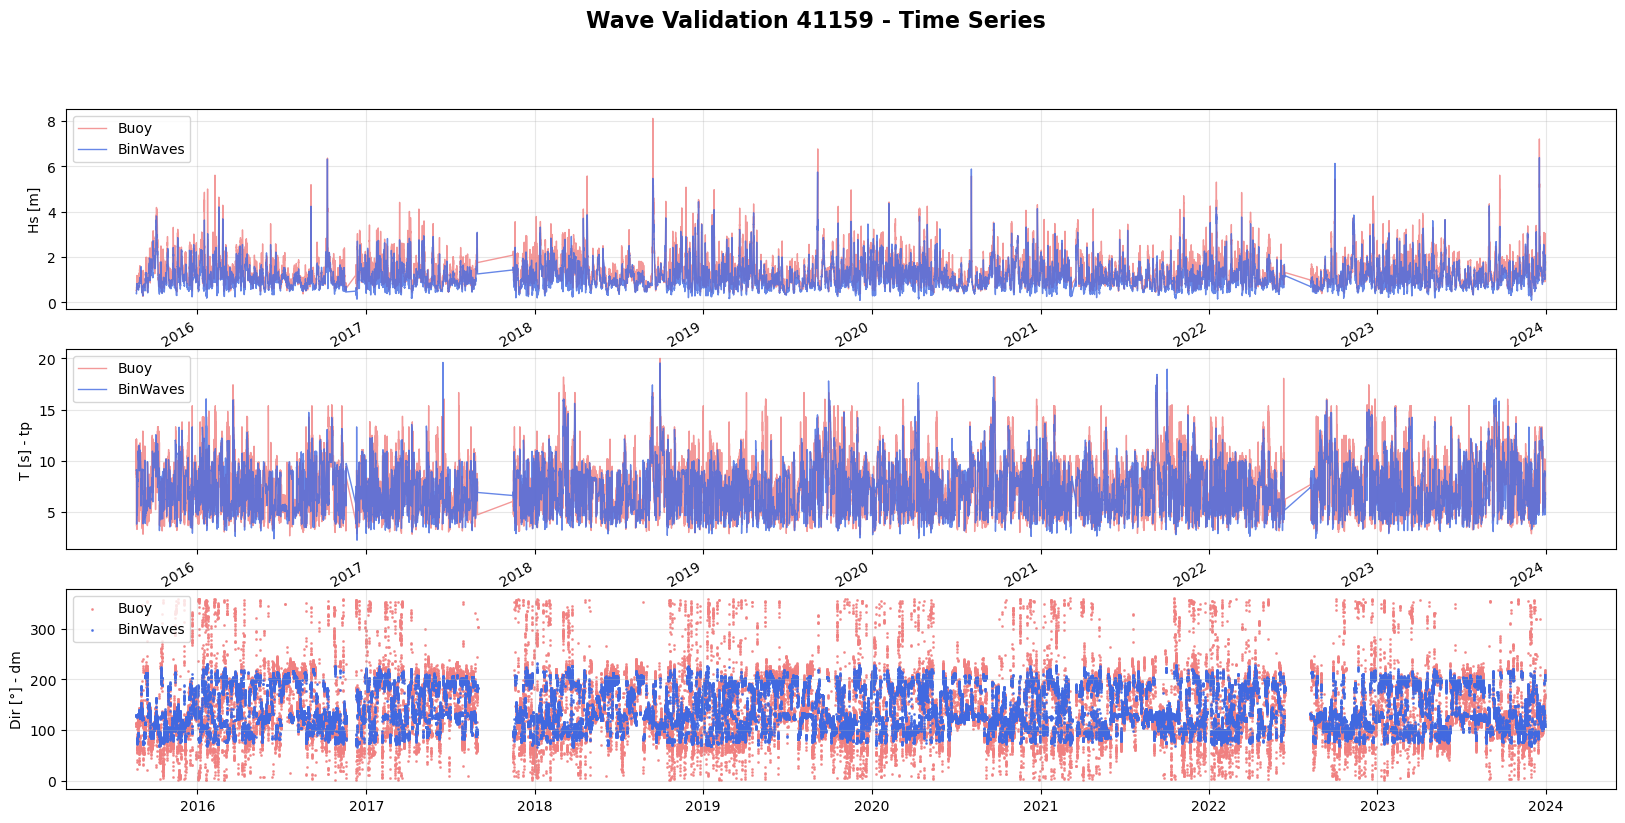

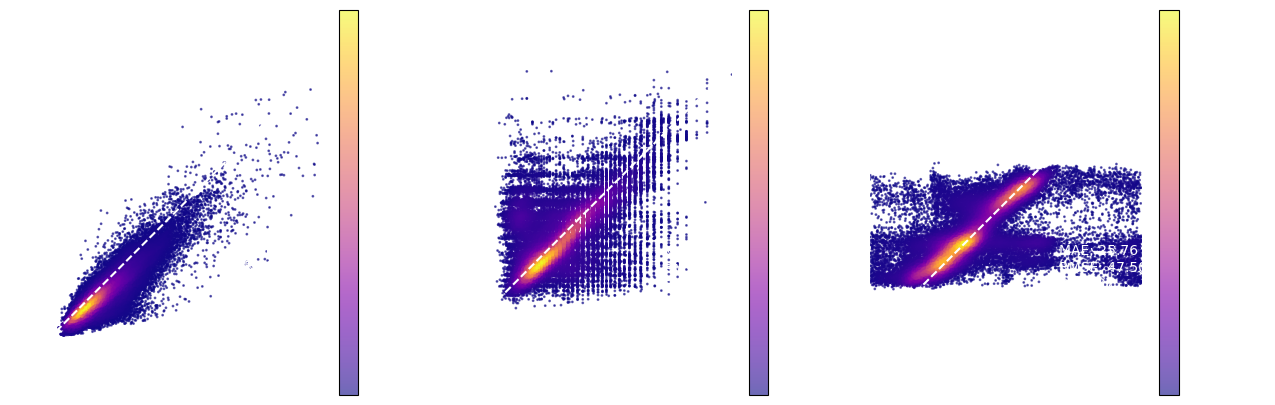

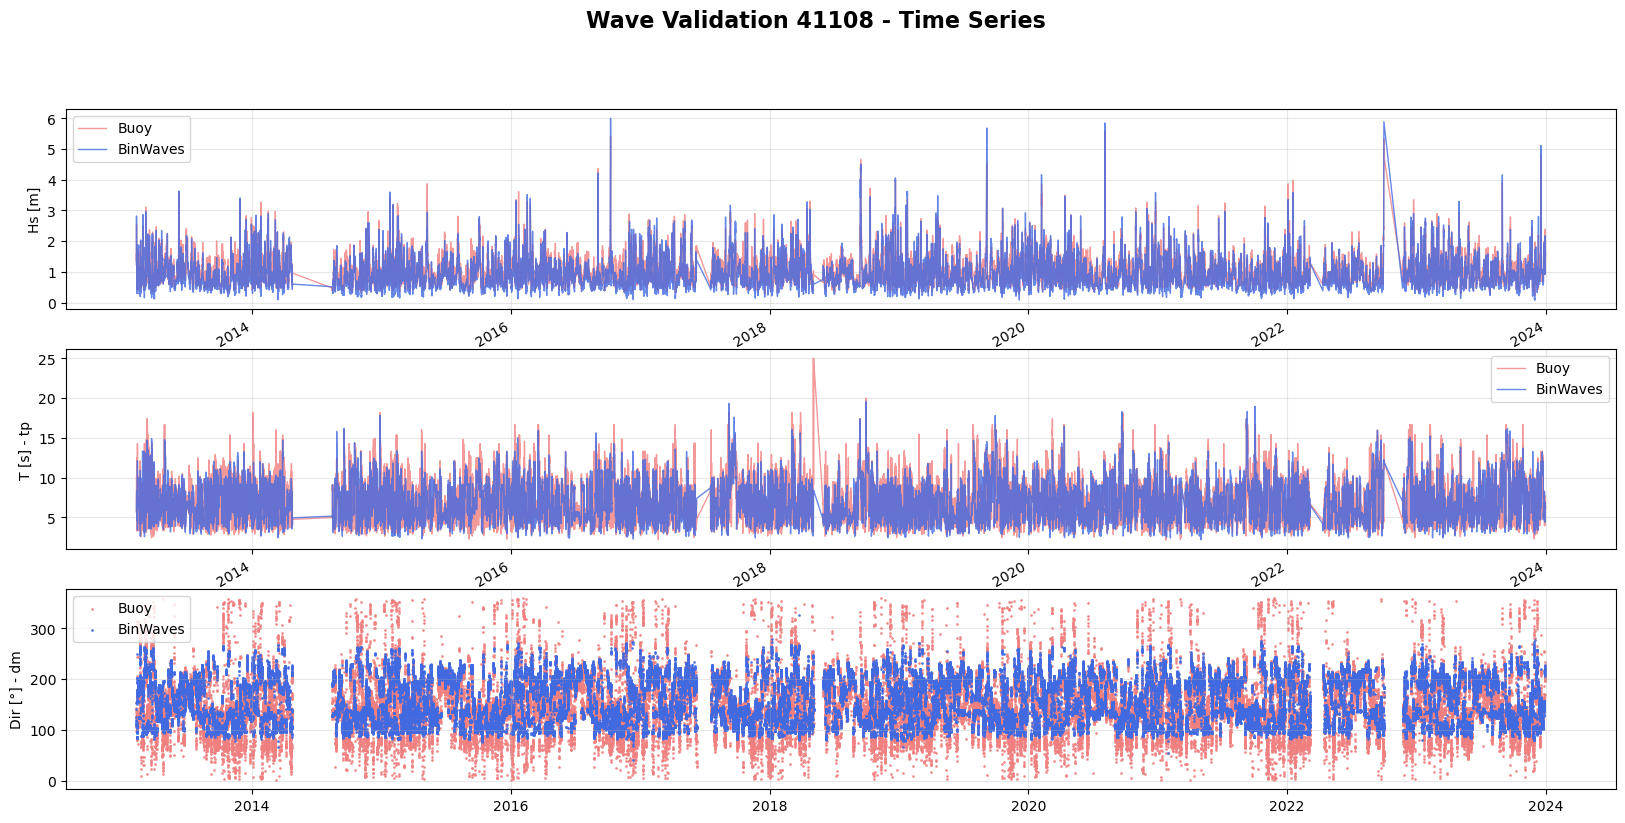

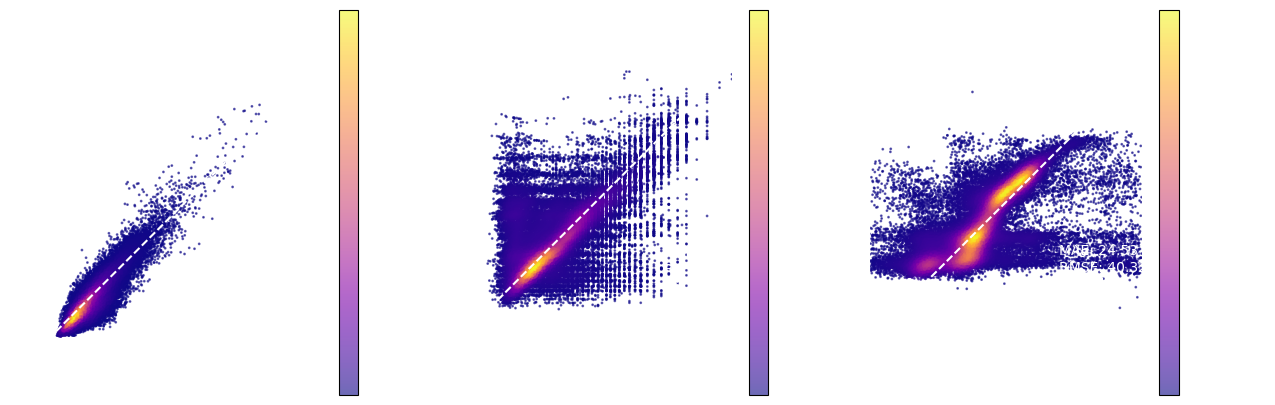

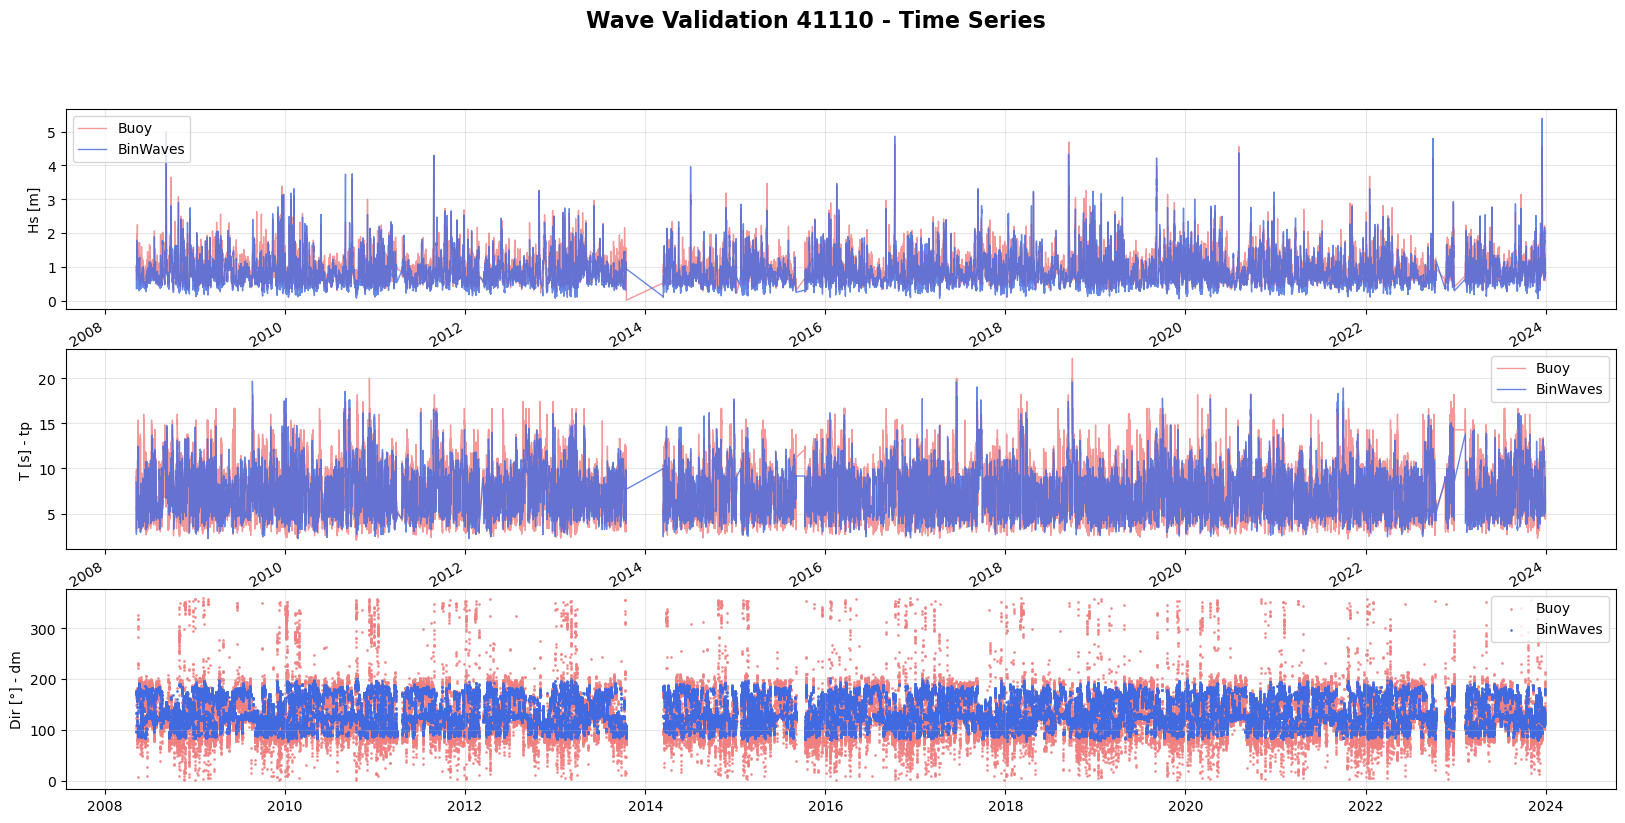

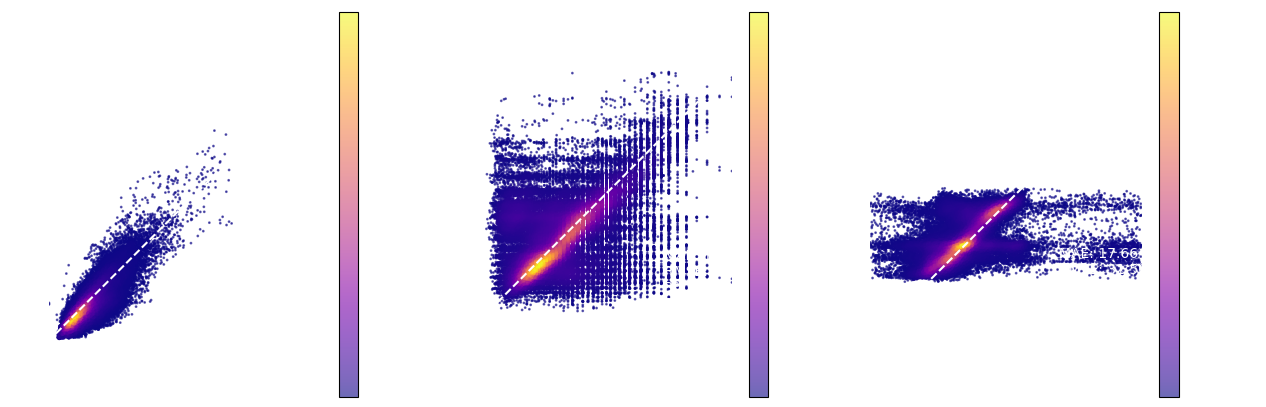

In [7]:
all_buoy_times = []
all_case_nums = set()
buoy_data_cache = {}  

for buoy_id in buoys.keys():
    result = load_buoy_data(buoy_id)
    if result is not None:
        buoy_waves, buoy_location, kp_coeffs, site_index = result
        buoy_times = pd.to_datetime(buoy_waves.index).round('1h').unique()
        all_buoy_times.extend(buoy_times)
        # kp_coeffs are already aggregated to 696 cases - use case_nums directly
        case_nums = kp_coeffs.case_num.values
        all_case_nums.update(case_nums)
        buoy_data_cache[buoy_id] = (buoy_waves, buoy_location, kp_coeffs, site_index)
        print(f"  Buoy {buoy_id}: {len(buoy_times)} time steps, {len(kp_coeffs.case_num)} cases")

# Find the time range that covers all buoys (min to max)
all_buoy_times = pd.to_datetime(all_buoy_times).unique()
buoy_time_min = all_buoy_times.min()
buoy_time_max = all_buoy_times.max()

print(f"\nBuoy data time range: {buoy_time_min} to {buoy_time_max}")
print(f"Total unique case_nums needed: {len(all_case_nums)}")

# Filter spectrum to only the time range where buoys have data
# This avoids processing 1979-1998 (or whenever buoys start) which no buoy needs
cawcr_spectrum_filtered = cawcr_spectrum.sel(time=slice(buoy_time_min, buoy_time_max))
print(f"Filtered spectrum from {len(cawcr_spectrum.time)} to {len(cawcr_spectrum_filtered.time)} time steps")
print(f"  (Removed ~{len(cawcr_spectrum.time) - len(cawcr_spectrum_filtered.time)} unnecessary time steps)")

# Transform offshore spectrum ONCE for all case_nums and all times
avg_buoy_times = len(cawcr_spectrum_filtered.time) / len(buoy_data_cache) if len(buoy_data_cache) > 0 else len(cawcr_spectrum_filtered.time)

offshore_spectra_all, offshore_spectra_case_all = transform_Offshore_spectrum(
    CAWCR_spectrum=cawcr_spectrum_filtered,
    subset_parameters=model_parameters,
    available_case_num=np.array(sorted(all_case_nums), dtype=int),  # Ensure integer type for indexing
    fixed_direction=True,
)

# Remove duplicates
_, unique_idx_offshore_case = np.unique(offshore_spectra_case_all.time, return_index=True)
offshore_spectra_case_all = offshore_spectra_case_all.isel(time=unique_idx_offshore_case)
_, unique_idx_offshore = np.unique(offshore_spectra_all.time, return_index=True)
offshore_spectra_all = offshore_spectra_all.isel(time=unique_idx_offshore)

print("✓ Offshore spectrum transformation complete!\n")

# Process all buoys
successful_buoys = []
failed_buoys = []

for buoy_id in buoys.keys():
    print(f"\n{'='*60}")
    print(f"Processing buoy: {buoy_id}")
    print(f"{'='*60}")
    
    try:
        # Use cached buoy data
        if buoy_id not in buoy_data_cache:
            print(f"Skipping buoy {buoy_id} - failed to load")
            failed_buoys.append(buoy_id)
            continue
            
        buoy_waves, buoy_location, kp_coeffs, site_index = buoy_data_cache[buoy_id]
        
        print(f"Buoy {buoy_id} coordinates: {buoy_location[0]}, {buoy_location[1]}")
        print(f"Selected kp_coeffs site coordinates: {kp_coeffs.coord_x.values}, {kp_coeffs.coord_y.values}")
        
        # Filter the already-transformed spectrum to this buoy's times and case_nums
        buoy_times = pd.to_datetime(buoy_waves.index).round('1h').unique()
        spectrum_times_filtered = pd.to_datetime(offshore_spectra_case_all.time.values)
        buoy_common_times = spectrum_times_filtered[spectrum_times_filtered.isin(buoy_times)]
        
        # Select times and case_nums for this buoy
        # kp_coeffs are already aggregated - use case_nums directly
        averaged_case_nums = kp_coeffs.case_num.values
        
        # Select offshore spectra for averaged case_nums
        offshore_spectra_case = offshore_spectra_case_all.sel(
            time=buoy_common_times,
            case_num=averaged_case_nums
        )
        offshore_spectra = offshore_spectra_all.sel(time=buoy_common_times)
        
        # Make sure buoy_waves has unique indices
        buoy_waves = buoy_waves[~buoy_waves.index.duplicated(keep="first")]
        
        if len(buoy_waves) == 0:
            print(f"Skipping buoy {buoy_id} - no valid data after deduplication")
            failed_buoys.append(buoy_id)
            continue
        
        # kp_coeffs are already aggregated to 696 cases in the propagation notebook
        # No aggregation needed here
        
        reconstructed_onshore_spectra = reconstruc_spectra(
            offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
            kp_coeffs=kp_coeffs,
            chunk_sizes={"time": 24*7},
            num_workers=15,
        )
        
        # Ensure all datasets have unique time values
        _, unique_idx_recon = np.unique(reconstructed_onshore_spectra.time, return_index=True)
        reconstructed_onshore_spectra = reconstructed_onshore_spectra.isel(time=unique_idx_recon)
        
        # Prepare data for plotting
        binwaves_spec = reconstructed_onshore_spectra.sel(
            time=buoy_waves.index, method="nearest"
        ).rename({"kps": "efth"}).squeeze().spec
        
        # Plot wave series
        print("Creating plots...")
        try:
            plot_wave_series(
                buoy_data=buoy_waves,
                binwaves_data=binwaves_spec,
                offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
                times=buoy_waves.index.values,
                save_plots=True,
                save_path="outputs/Figures/",
                title_prefix=f"Wave Validation {buoy_id}",
                scatter_style=SCATTER_STYLE,
                kde_cmap=KDE_CMAP,
                kde_alpha=KDE_ALPHA,
            )
            print(f"✓ Plots saved for buoy {buoy_id}")
        except Exception as e:
            print(f"Warning: Could not create plots for buoy {buoy_id}: {e}")
        
        # Save CSV files
        print("Saving CSV files...")
        try:
            # Round and group the buoy index
            buoy_waves_rounded = buoy_waves.copy()
            buoy_waves_rounded.index = pd.to_datetime(buoy_waves_rounded.index).round('1h')
            buoy_waves_rounded = buoy_waves_rounded.groupby(buoy_waves_rounded.index).mean()
            
            # Extract binwaves data
            binwaves_spec_rounded = reconstructed_onshore_spectra.sel(
                time=buoy_waves_rounded.index, method="nearest"
            ).rename({"kps": "efth"}).squeeze().spec
            
            binwaves_hs = binwaves_spec_rounded.hs().values
            binwaves_tp = binwaves_spec_rounded.tp().values
            binwaves_dpm = binwaves_spec_rounded.dpm().values
            
            # Save CSV files
            hourly_file, daily_file = save_validation_csv_with_interpolation(
                buoy_data=buoy_waves_rounded,
                binwaves_hs=binwaves_hs,
                binwaves_tp=binwaves_tp,
                binwaves_dpm=binwaves_dpm,
                buoy_id=buoy_id,
                save_path="outputs/time_series/",
                filename_prefix="buoy_validation",
                target_resolution="1d"
            )
            print(f"✓ CSV files saved for buoy {buoy_id}")
        except Exception as e:
            print(f"Warning: Could not save CSV files for buoy {buoy_id}: {e}")
        
        successful_buoys.append(buoy_id)
        print(f"✓ Successfully processed buoy {buoy_id}")
        
    except Exception as e:
        print(f"✗ Error processing buoy {buoy_id}: {e}")
        import traceback
        traceback.print_exc()
        failed_buoys.append(buoy_id)

print(f"\n{'='*60}")
print("Processing complete!")
print(f"{'='*60}")
print(f"Successfully processed: {len(successful_buoys)} buoys")
print(f"Successful buoys: {successful_buoys}")
if failed_buoys:
    print(f"\nFailed buoys: {len(failed_buoys)}")
    print(f"Failed buoy IDs: {failed_buoys}")
